# DeepAgent 기반의 Research Agent

In [16]:
from dotenv import load_dotenv

load_dotenv(".env", override=True)

True

In [17]:
from research_agent.tools import tavily_search, think_tool

research_tools = [tavily_search, think_tool]

## 태스크 특화 프롬프트
 
[에이전트를 위한 몇 가지 프롬프팅 기법](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA)을 활용해서  
태스크 특화 프롬프트를 정의해 보겠습니다:

### 1. 에이전트처럼 생각하기 (Think Like The Agent)
새로 온 동료에게 어떤 지침을 줄지 생각해 보세요.
- **질문을 꼼꼼히 읽기** - 사용자가 정확히 어떤 정보를 원하는지 파악합니다.
- **처음에는 넓게 검색하기** - 포괄적이고 광범위한 쿼리로 시작합니다.
- **각 검색 이후 잠시 멈추고 평가하기** - 지금까지의 정보로 답할 수 있는지, 무엇이 아직 부족한지 확인합니다.
- **정보를 모아 가며 더 좁은 검색 실행하기** - 남은 빈틈을 채우기 위해 점점 더 구체적인 검색을 합니다.

---

### 2. 구체적인 휴리스틱 조건 제시 (과도한 도구 호출 방지)
연구 에이전트가 도구를 과도하게 호출하지 않도록 **하드 리밋(Hard Limits)**을 사용합니다:
- **자신 있게 답할 수 있을 때 멈추기** - 완벽함을 위해 끝없이 검색하지 않습니다.
- **예산 정하기** - 단순한 질의는 검색 도구 2–3회, 복잡한 질의는 최대 5회까지만 사용합니다.
- **상한선 유지** - 적절한 소스를 찾지 못해도 검색 도구 호출은 항상 5회를 넘지 않습니다.

---

### 3. 생각의 과정을 드러내기
각 검색 도구 호출 이후에는 [`think_tool`을 사용해 결과를 분석](https://www.anthropic.com/engineering/claude-think-tool)합니다:
- 어떤 핵심 정보를 찾았는가?
- 아직 무엇이 부족한가?
- 질문에 충분히 포괄적으로 답할 수 있을 만큼 정보가 모였는가?
- 더 검색해야 할지, 아니면 이제 답변을 작성해야 할지?

In [18]:
from datetime import datetime

from research_agent.prompts import (
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)
from utils import format_messages, show_prompt

In [19]:
import pytz

tz = pytz.timezone("Asia/Seoul")

# Get current date
current_date = datetime.now(tz=tz).strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research_agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

In [8]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

### DeepAgent 기반의 Research Orchestrator 에이전트 생성하기

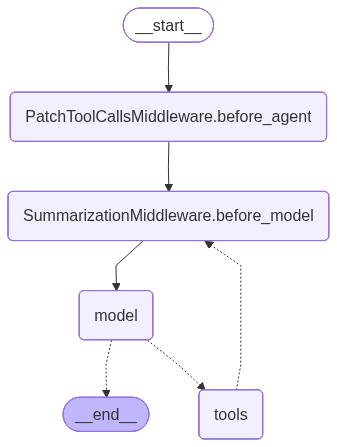

In [20]:
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model

# Create the agent
agent = create_deep_agent(
    init_chat_model(model="openai:gpt-4.1", temperature=0.0),
    research_tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
)

agent

In [10]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Research context engineering approaches used to build AI agents. Speak in Korean.",
            }
        ],
    },
)

In [13]:
format_messages(result["messages"])

╭───────────────────────────────────────────────────── Human ─────────────────────────────────────────────────────╮
│ Research context engineering approaches used to build AI agents. Speak in Korean.                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────────── AI ───────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ Tool Call: write_todos                                                                                          │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "사용자 요청을 /research_request.md 파일에 저장",                                              │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링 접근법에 대해 리서치할 하위 에이전트에게      │
│ 위임",                                                                                                          │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "하위 에이전트의 리서치 결과를 종합하고 인용 출처를 정리",                                     │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "최종 보고서를 /final_report.md 파일에 작성 (한국어, 구조화된 보고서, 인용 포함)",             │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "/research_request.md 파일을 읽고 모든 요구사항이 충족되었는지 검증",                          │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_0XEQ64ZUjo66IiPfHQJ1pSQE                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│ Updated todo list to [{'content': '사용자 요청을 /research_request.md 파일에 저장', 'status': 'in_progress'},   │
│ {'content': 'AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링 접근법에 대해 리서치할 하위 에이전트에게 위임',    │
│ 'status': 'pending'}, {'content': '하위 에이전트의 리서치 결과를 종합하고 인용 출처를 정리', 'status':          │
│ 'pending'}, {'content': '최종 보고서를 /final_report.md 파일에 작성 (한국어, 구조화된 보고서, 인용 포함)',      │
│ 'status': 'pending'}, {'content': '/research_request.md 파일을 읽고 모든 요구사항이 충족되었는지 검증',         │
│ 'status': 'pending'}]                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────────── AI ───────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ Tool Call: write_file                                                                                           │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링 접근법에 대해 리서치하라. (한국어로 작성)"        │
│ }                                                                                                               │
│    ID: call_aANm7pwtqLohBH3htWiEqJ68                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭────────────────────────────────────────────────────── AI ───────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ Tool Call: read_file                                                                                            │
│    Args: {                                                                                                      │
│   "file_path": "/final_report.md"                                                                               │
│ }                                                                                                               │
│    ID: call_e7O07DyLgppsYbt2GdrvecAn                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│      1  ## AI 에이전트 컨텍스트 엔지니어링 접근법                                                               │
│      2                                                                                                          │
│      3  ### 1. 개요                                                                                             │
│      4                                                                                                          │
│      5  컨텍스트 엔지니어링(Context Engineering)은 AI 에이전트가 상황에 맞는 정확한 판단과 행동을 할 수 있도록, │
│ 필요한 정보(컨텍스트)를 체계적으로 설계하고 관리하는 기술적 접근법입니다. 기존의 프롬프트 엔지니어링이 단일     │
│ 질의-응답에 집중했다면, 컨텍스트 엔지니어링은 에이전트가 장기적·복합적 작업을 수행할 수 있도록 정보의 흐름,     │
│ 구조, 업데이트, 검증까지 포괄합니다[1][2].                                                                      │
│      6                                                                                                          │
│      7  ### 2. 주요 방법론                                                                                      │
│      8                                                                                                          │
│      9  #### 2.1 컨텍스트 관리 4대 전략[2]                                                                      │
│     10  - **작성(Writing):** 명확한 시스템 프롬프트와 지침을 작성해 에이전트의 역할, 한계, 기대 행동을          │
│ 구체적으로 전달                                                                                                 │
│     11  - **선택(Selecting):** 방대한 데이터 중 현재 작업에 필요한 정보만 선별(검색, 태깅, 중요도 평가 등)      │
│     12  - **압축(Compressing):** 긴 문서나 대화 이력을 요약·정제해 컨텍스트 윈도우 내에 핵심 정보만 담음        │
│     13  - **분리(Isolating):** 지침, 사용자 입력, 참고 데이터 등 정보를 논리적으로 분리해 혼동 방지             │
│     14                                                                                                          │
│     15  #### 2.2 컨텍스트 엔지니어링 5대 원칙[2]                                                                │
│     16  - **명시적 정보 제공:** 에이전트가 반드시 알아야 할 정보를 명확히 전달(암묵적 기대 금지)                │
│     17  - **구조화된 정보 아키텍처:** 계층적·구조적으로 정보를 정리(정책, 절차, 세션 데이터 등)                 │
│     18  - **동적 컨텍스트 관리:** 상황 변화에 따라 컨텍스트를 실시간으로 업데이트                               │
│     19  - **최소 필요 컨텍스트:** 과도한 정보 제공을 피하고, 현재 작업에 꼭 필요한 정보만 제공                  │
│     20  - **검증 가능한 컨텍스트:** 에이전트가 정보를 올바르게 해석하는지 테스트 및 검증                        │
│     21                                                                                                          │
│     22  ### 3. 실제 적용 사례                                                                                   │
│     23                                                                                                          │
│     24  - **AI 리서치 어시스턴트(Inngest 사례)[1]:**                                                            │
│     25    - 다양한 데이터 소스(ArXiv, GitHub, 웹, PDF 등)에서 정보를 병렬로 수집                                │
│     26    - 수집된 정보를 여러 특화 LLM(분석, 요약, 팩트체크, 분류 등)으로 압축·정제                            │
│     27    - 오케스트레이터-워커 패턴을 활용해, 각 워커가 가공한 정보를 종합하여 최적의 답변 생성                │
│     28    - 각 단계에서 오류 복구, 속도 최적화, API 레이트 리밋 관리 등 엔지니어링 기법 적용                    │
│     29                                                                                                          │
│     30  - **일반적 에이전트 적용 예시[2]:**                                                                     │
│     31    - 고객 서비스 에이전트: 주문, 재고, 환불 등 여러 시스템과 연동하며, 각 단계별로 필요한 컨텍스트만     │
│ 동적으로 관리                                                                                                   │
│     32    - 코드 어시스턴트: 대규모 코드베이스에서 필요한 파일·함수만 선별적으로 불러와 컨텍스트로 활용         │
│     33                                                                                                          │
│     34  ### 4. 최신 동향 및 시사점                                                                              │
│     35                                                                   

╭────────────────────────────────────────────────────── AI ───────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ Tool Call: write_todos                                                                                          │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "사용자 요청을 /research_request.md 파일에 저장",                                              │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링 접근법에 대해 리서치할 하위 에이전트에게      │
│ 위임",                                                                                                          │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "하위 에이전트의 리서치 결과를 종합하고 인용 출처를 정리",                                     │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "최종 보고서를 /final_report.md 파일에 작성 (한국어, 구조화된 보고서, 인용 포함)",             │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "/research_request.md 파일을 읽고 모든 요구사항이 충족되었는지 검증",                          │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_eTV81dwS59n2lh7nGqLhTdli                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│ Updated todo list to [{'content': '사용자 요청을 /research_request.md 파일에 저장', 'status': 'completed'},     │
│ {'content': 'AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링 접근법에 대해 리서치할 하위 에이전트에게 위임',    │
│ 'status': 'completed'}, {'content': '하위 에이전트의 리서치 결과를 종합하고 인용 출처를 정리', 'status':        │
│ 'completed'}, {'content': '최종 보고서를 /final_report.md 파일에 작성 (한국어, 구조화된 보고서, 인용 포함)',    │
│ 'status': 'completed'}, {'content': '/research_request.md 파일을 읽고 모든 요구사항이 충족되었는지 검증',       │
│ 'status': 'completed'}]                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────────── AI ───────────────────────────────────────────────────────╮
│ AI 에이전트 구축에 사용되는 컨텍스트 엔지니어링(context engineering) 접근법에 대한 심층 보고서를 완성했습니다.  │
│ 주요 개념, 대표적인 방법론, 실제 적용 사례, 최신 연구 동향 및 시사점까지 모두 한국어로 구조화하여 정리하였으며, │
│ 신뢰할 수 있는 출처를 명확히 인용하였습니다.                                                                    │
│                                                                                                                 │
│ 최종 보고서는 /final_report.md 파일에 저장되어 있습니다. 궁금하신 점이나 추가 요청이 있으시면 말씀해 주세요!    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [14]:
from deepagents.backends.utils import file_data_to_string

file_content = file_data_to_string(result["files"]["/final_report.md"])
show_prompt(file_content)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ## AI 에이전트 컨텍스트 엔지니어링 접근법                                                                      │
│                                                                                                                 │
│  ### 1. 개요                                                                                                    │
│                                                                                                                 │
│  컨텍스트 엔지니어링(Context Engineering)은 AI 에이전트가 상황에 맞는 정확한 판단과 행동을 할 수 있도록,        │
│  필요한 정보(컨텍스트)를 체계적으로 설계하고 관리하는 기술적 접근법입니다. 기존의 프롬프트 엔지니어링이 단일    │
│  질의-응답에 집중했다면, 컨텍스트 엔지니어링은 에이전트가 장기적·복합적 작업을 수행할 수 있도록 정보의 흐름,    │
│  구조, 업데이트, 검증까지 포괄합니다[1][2].                                                                     │
│                                                                                                                 │
│  ### 2. 주요 방법론                                                                                             │
│                                                                                                                 │
│  #### 2.1 컨텍스트 관리 4대 전략[2]                                                                             │
│  - **작성(Writing):** 명확한 시스템 프롬프트와 지침을 작성해 에이전트의 역할, 한계, 기대 행동을 구체적으로      │
│  전달                                                                                                           │
│  - **선택(Selecting):** 방대한 데이터 중 현재 작업에 필요한 정보만 선별(검색, 태깅, 중요도 평가 등)             │
│  - **압축(Compressing):** 긴 문서나 대화 이력을 요약·정제해 컨텍스트 윈도우 내에 핵심 정보만 담음               │
│  - **분리(Isolating):** 지침, 사용자 입력, 참고 데이터 등 정보를 논리적으로 분리해 혼동 방지                    │
│                                                                                                                 │
│  #### 2.2 컨텍스트 엔지니어링 5대 원칙[2]                                                                       │
│  - **명시적 정보 제공:** 에이전트가 반드시 알아야 할 정보를 명확히 전달(암묵적 기대 금지)                       │
│  - **구조화된 정보 아키텍처:** 계층적·구조적으로 정보를 정리(정책, 절차, 세션 데이터 등)                        │
│  - **동적 컨텍스트 관리:** 상황 변화에 따라 컨텍스트를 실시간으로 업데이트                                      │
│  - **최소 필요 컨텍스트:** 과도한 정보 제공을 피하고, 현재 작업에 꼭 필요한 정보만 제공                         │
│  - **검증 가능한 컨텍스트:** 에이전트가 정보를 올바르게 해석하는지 테스트 및 검증                               │
│                                                                                                                 │
│  ### 3. 실제 적용 사례                                                                                          │
│                                                                                                                 │
│  - **AI 리서치 어시스턴트(Inngest 사례)[1]:**                                                                   │
│    - 다양한 데이터 소스(ArXiv, GitHub, 웹, PDF 등)에서 정보를 병렬로 수집                                       │
│    - 수집된 정보를 여러 특화 LLM(분석, 요약, 팩트체크, 분류 등)으로 압축·정제                                   │
│    - 오케스트레이터-워커 패턴을 활용해, 각 워커가 가공한 정보를 종합하여 최적의 답변 생성                       │
│    - 각 단계에서 오류 복구, 속도 최적화, API 레이트 리밋 관리 등 엔지니어링 기법 적용                           │
│                                                                                                                 │
│  - **일반적 에이전트 적용 예시[2]:**                                                                            │
│    - 고객 서비스 에이전트: 주문, 재고, 환불 등 여러 시스템과 연동하며, 각 단계별로 필요한 컨텍스트만 동적으로   │
│  관리                                                                                                           │
│    - 코드 어시스턴트: 대규모 코드베이스에서 필요한 파일·함수만 선별적으로 불러와 컨텍스트로 활용                │
│                                                                                                                 │
│  ### 4. 최신 동향 및 시사점                                              